In [128]:
from sklearn.datasets import load_digits

data = load_digits()
data.data.shape, data.target.max(), data.target.min()

((1797, 64), np.int64(9), np.int64(0))

In [129]:
from sklearn.preprocessing import StandardScaler

X_scale = StandardScaler().fit_transform(data.data)
X_scale

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]], shape=(1797, 64))

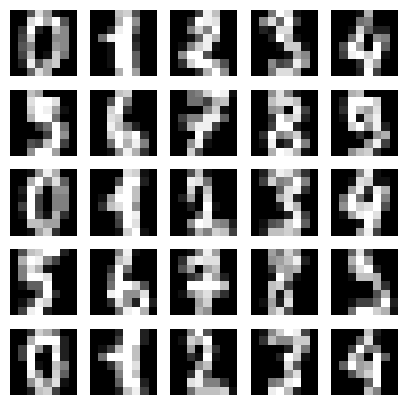

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=[5,5])
for i in range(0,25):
    plt.subplot(5, 5, i+1)
    plt.imshow(data.images[i], cmap="gray")
    plt.axis('off')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import silhouette_score

labels = np.array([])
wcsses = np.array([])
silhouettes = np.array([])

n_clusters = range(6,15)

for n_cluster in n_clusters:
    km = KMeans(
        n_clusters=n_cluster,
        random_state=42)
    label = km.fit_predict(X_scale)
    labels = np.append(labels, label)
    wcsses = np.append(wcsses, km.inertia_)
    silhouettes = np.append(silhouettes, silhouette_score(X_scale,label))
labels = labels.reshape(9,X_scale.shape[0])

array([1., 2., 3., ..., 2., 4., 4.], shape=(1797,))

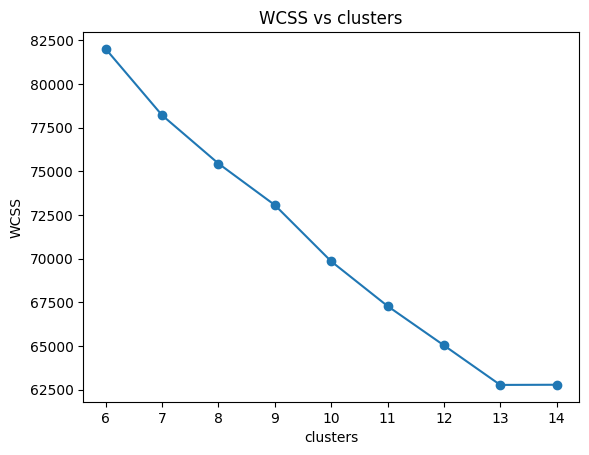

In [167]:
plt.plot(n_clusters,wcsses,marker='o')
plt.title("WCSS vs clusters")
plt.xlabel("clusters")
plt.ylabel("WCSS")
plt.show()

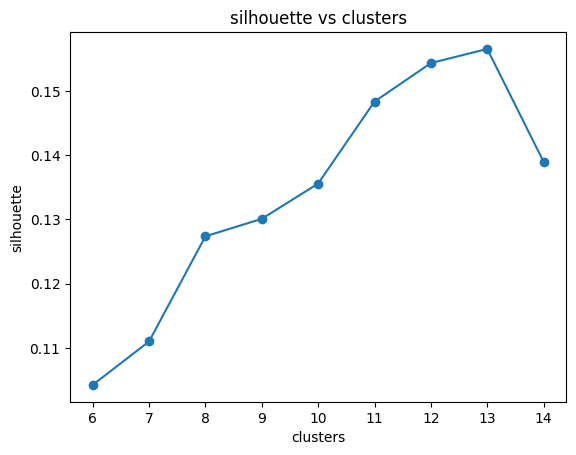

In [168]:
plt.plot(n_clusters,silhouettes,marker='o')
plt.title("silhouette vs clusters")
plt.xlabel("clusters")
plt.ylabel("silhouette")
plt.show()

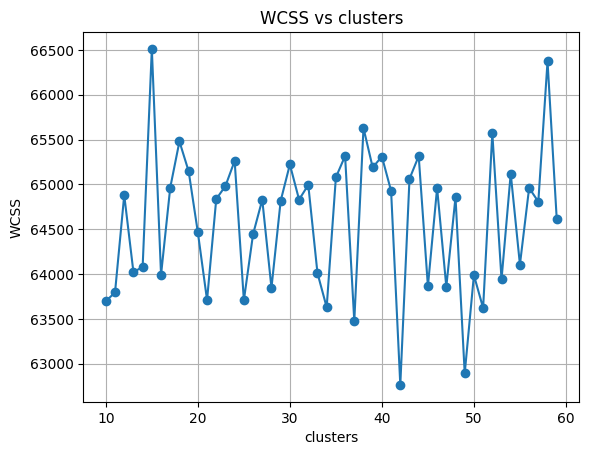

In [169]:
wcsses = np.array([])

states = range(10,60)

for state in states:
    km = KMeans(
        n_clusters=13,
        random_state=state)
    km.fit(X_scale)
    wcsses = np.append(wcsses, km.inertia_)

plt.plot(states,wcsses,marker='o')
plt.title("WCSS vs clusters")
plt.xlabel("clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

accuracy : 0.666110183639399
true label      : [0 1 2 3 4 5 6 7 8 9]
predicted label : [5 8 6 7 2 1 4 3 9 0]
predicted count : [ 30 139 232 194 180 178 170 413   2 259]


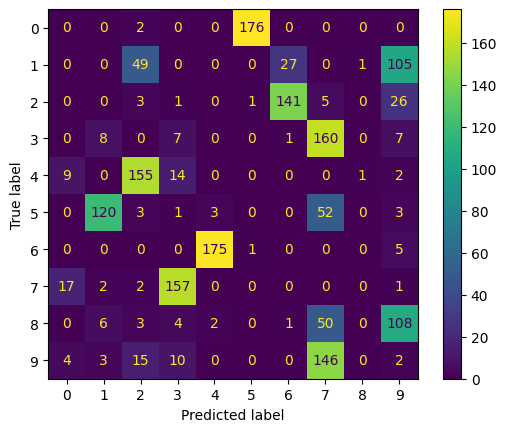

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.optimize import linear_sum_assignment

def clustering_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    # Hungarian maximization
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    accuracy = cm[row_ind, col_ind].sum() / np.sum(cm)
    return accuracy,row_ind,col_ind,cm

accuracy,row_ind,col_ind,cm = clustering_accuracy(data.target,labels[4])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
print(f"accuracy : {accuracy}")
print(f"true label      : {row_ind}")
print(f"predicted label : {col_ind}")
print(f"predicted count : {cm.sum(axis=0)}")

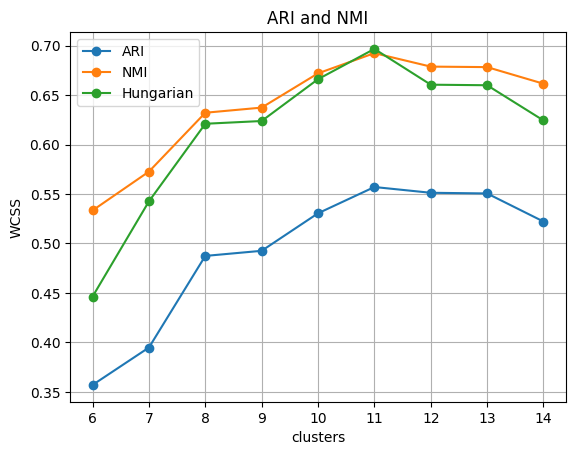

In [217]:
from sklearn.metrics.cluster import adjusted_rand_score , normalized_mutual_info_score

aris = np.array([])
nmis = np.array([])
hungs = np.array([])

y=data.target

labels = np.array([])
wcsses = np.array([])
silhouettes = np.array([])

n_clusters = range(6,15)

for n_cluster in n_clusters:
    km = KMeans(
        n_clusters=n_cluster,
        random_state=42)
    label = km.fit_predict(X_scale)
    labels = np.append(labels, label)
    wcsses = np.append(wcsses, km.inertia_)
    silhouettes = np.append(silhouettes, silhouette_score(X_scale,label))
labels = labels.reshape(9,X_scale.shape[0])

for label in labels:
    aris = np.append(aris,adjusted_rand_score(y,label))
    nmis = np.append(nmis,normalized_mutual_info_score(y,label))
    hungs = np.append(hungs, clustering_accuracy(y,label)[0])

plt.plot(n_clusters,aris,marker='o',label='ARI')
plt.plot(n_clusters,nmis,marker='o',label='NMI')
plt.plot(n_clusters,hungs,marker='o',label='Hungarian')
plt.title("ARI and NMI")
plt.xlabel("clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.legend()
plt.show()